In [1]:
import pandas as pd

etf_raw = pd.read_excel('Spot ETFS for Major Global Indices.xlsx', sheet_name='Sheet2', header=None)


In [2]:
ticker_names = ['SPY US Equity', 'QQQ US Equity', 'EWJ US Equity', 'ASHR US Equity',
                'EWH US Equity', 'FEZ US Equity', 'INDA US Equity', 'CAC FP Equity', 'ISF LN Equity']
columns = ['Date'] + ticker_names


## Backtesting


simple strategies


In [3]:
row_index = etf_raw[etf_raw.eq("SPY US Equity").any(axis=1)].index[0]
data = etf_raw.iloc[row_index + 1:, :len(columns)].copy()
data.columns = columns
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
df = data.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)

results = {}
for ticker in ticker_names:
    temp = df[['Date', ticker]].copy()
    temp = temp.rename(columns={ticker: 'Price'}).dropna()
    if len(temp) < 15:
        continue
    temp['SMA_10'] = temp['Price'].rolling(10).mean()
    temp['SMA_Signal'] = (temp['Price'] > temp['SMA_10']).astype(int)
    temp['Momentum'] = temp['Price'] - temp['Price'].shift(5)
    temp['Momentum_Signal'] = (temp['Momentum'] > 0).astype(int)
    temp['Reversal'] = temp['Price'].pct_change()
    temp['Reversal_Signal'] = (temp['Reversal'] < -0.03).astype(int)

    last = temp.dropna().iloc[-1]
    results[ticker] = {
        'SMA': 'Long' if last['SMA_Signal'] == 1 else 'Short',
        'Momentum': 'Long' if last['Momentum_Signal'] == 1 else 'Short',
        'Reversal': 'Long' if last['Reversal_Signal'] == 1 else 'No Trade'
    }

signals_df = pd.DataFrame(results).T.reset_index()
signals_df.columns = ['Ticker', 'SMA', 'Momentum', 'Reversal']
signals_df.to_csv('signals_summary.csv', index=False)

signals_df


<ipython-input-3-81a37698a890>:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
<ipython-input-3-81a37698a890>:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp['Reversal'] = temp['Price'].pct_change()
<ipython-input-3-81a37698a890>:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp['Reversal'] = temp['Price'].pct_change()
<ipython-input-3-81a37698

,Ticker,SMA,Momentum,Reversal
0,SPY US Equity,Short,Short,No Trade
1,QQQ US Equity,Short,Short,No Trade
2,EWJ US Equity,Long,Short,No Trade
3,ASHR US Equity,Short,Short,No Trade
4,EWH US Equity,Short,Short,No Trade
5,FEZ US Equity,Long,Long,No Trade
6,INDA US Equity,Long,Long,No Trade
7,CAC FP Equity,Short,Short,No Trade
8,ISF LN Equity,Short,Short,No Trade


,Ticker,SMA,Momentum,Reversal
0,SPY US Equity,Short,Short,No Trade
1,QQQ US Equity,Short,Short,No Trade
3,ASHR US Equity,Short,Short,No Trade
4,EWH US Equity,Short,Short,No Trade
5,FEZ US Equity,Long,Long,No Trade
6,INDA US Equity,Long,Long,No Trade
7,CAC FP Equity,Short,Short,No Trade
8,ISF LN Equity,Short,Short,No Trade


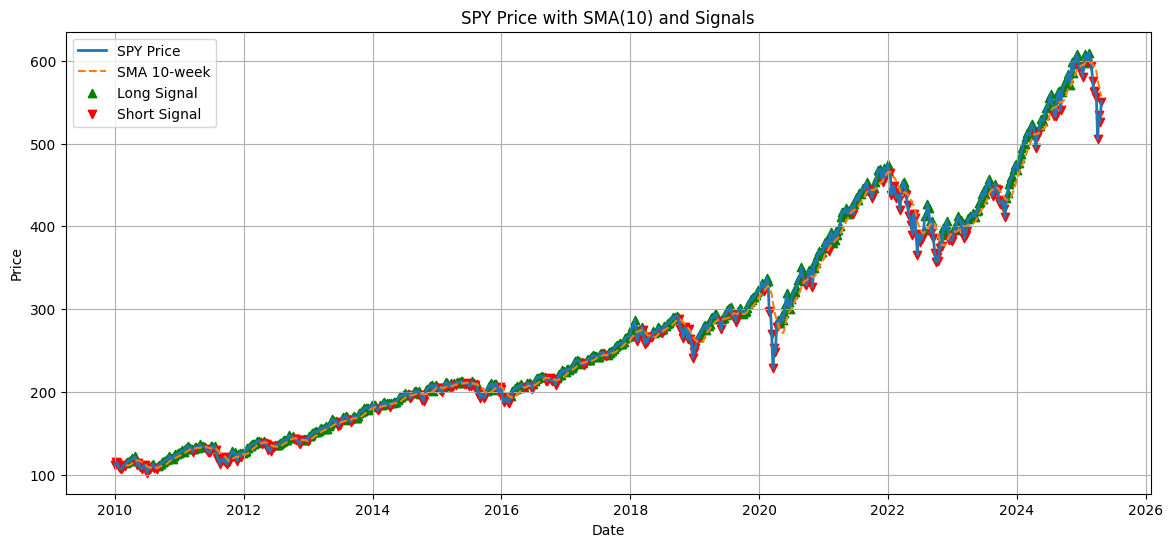

In [4]:
import matplotlib.pyplot as plt


spy = df[['Date', 'SPY US Equity']].dropna()
spy = spy.rename(columns={'SPY US Equity': 'Price'})
spy['SMA_10'] = spy['Price'].rolling(10).mean()
spy['Signal'] = (spy['Price'] > spy['SMA_10']).astype(int)


plt.figure(figsize=(14,6))
plt.plot(spy['Date'], spy['Price'], label='SPY Price', linewidth=2)
plt.plot(spy['Date'], spy['SMA_10'], label='SMA 10-week', linestyle='--')

longs = spy[spy['Signal'] == 1]
shorts = spy[spy['Signal'] == 0]
plt.scatter(longs['Date'], longs['Price'], marker='^', color='green', label='Long Signal')
plt.scatter(shorts['Date'], shorts['Price'], marker='v', color='red', label='Short Signal')

plt.title('SPY Price with SMA(10) and Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


SMA crossover

In [16]:

xls = pd.ExcelFile("/content/Spot ETFS for Major Global Indices.xlsx")


df_raw = xls.parse(xls.sheet_names[0])

tickers = df_raw.iloc[2]
labels = df_raw.iloc[3]


columns = []
for t, l in zip(tickers, labels):
    if pd.isna(t) or pd.isna(l):
        columns.append(None)
    else:
        columns.append(str(t).split()[0])

columns[0] = "Date"
df_prices = df_raw.iloc[4:].copy()
df_prices.columns = columns
df_prices = df_prices.loc[:, df_prices.columns.notna()]


df_prices["Date"] = pd.to_datetime(df_prices["Date"])
df_prices.set_index("Date", inplace=True)

etf_prices = df_prices.apply(pd.to_numeric, errors="coerce")
etf_prices

,SPY,QQQ,EWJ,ASHR,EWH,FEZ,INDA,CAC,ISF
Date,,,,,,,,,
2010-01-01,111.44,45.75,38.96,NaN,15.66,41.48,NaN,39.730,540.3
2010-01-08,114.57,46.55,40.48,NaN,16.27,42.84,NaN,40.620,553.0
2010-01-15,113.64,45.85,41.88,NaN,15.71,41.63,NaN,39.730,544.6
2010-01-22,109.21,44.16,40.68,NaN,14.85,38.70,NaN,38.355,530.5
2010-01-29,107.39,42.79,39.36,NaN,14.63,37.44,NaN,37.640,518.7
...,...,...,...,...,...,...,...,...,...
2025-03-28,555.66,468.94,69.22,26.62,17.56,55.01,51.28,77.900,845.3
2025-04-04,505.28,422.67,61.51,25.21,16.38,50.27,49.19,71.720,786.8
2025-04-11,533.94,454.40,65.82,25.71,15.97,52.75,50.76,70.140,781.2


In [17]:
def generate_sma_crossover_all(etf_df, short_window=5, long_window=20):
    all_signals = []

    for ticker in etf_df.columns:
        prices = etf_df[ticker].dropna()
        short_sma = prices.rolling(window=short_window).mean()
        long_sma = prices.rolling(window=long_window).mean()

        signal = pd.Series("No Trade", index=prices.index)

        long_cond = (short_sma > long_sma) & (short_sma.shift(1) <= long_sma.shift(1))
        short_cond = (short_sma < long_sma) & (short_sma.shift(1) >= long_sma.shift(1))

        signal[long_cond] = "Long"
        signal[short_cond] = "Short"

        df_signals = pd.DataFrame({
            "Ticker": ticker,
            "Date": prices.index,
            "Price": prices.values,
            f"SMA_{short_window}": short_sma.values,
            f"SMA_{long_window}": long_sma.values,
            "Signal": signal.values
        })

        all_signals.append(df_signals)

    return pd.concat(all_signals, ignore_index=True)


In [23]:
sma_crossover_signals = generate_sma_crossover_all(etf_prices)

all_trade_signals = sma_crossover_signals[sma_crossover_signals["Signal"] != "No Trade"]
display(all_trade_signals)

all_trade_signals.to_csv("sma_crossover_all_signals.csv", index=False)


,Ticker,Date,Price,SMA_5,SMA_20,Signal
21,SPY,2010-05-28,109.369,112.4893,113.502550,Short
37,SPY,2010-09-17,112.490,109.8504,109.359225,Long
75,SPY,2011-06-10,127.600,131.8360,132.142500,Short
81,SPY,2011-07-22,134.580,132.2800,131.999500,Long
83,SPY,2011-08-05,120.080,130.0160,131.540000,Short
...,...,...,...,...,...,...
6865,ISF,2024-11-08,786.600,799.5800,802.375000,Short
6871,ISF,2024-12-20,785.500,803.3000,803.090000,Long
6872,ISF,2024-12-27,791.200,800.3200,802.810000,Short
6876,ISF,2025-01-24,827.100,809.2400,802.970000,Long


In [24]:
def compute_pnl(signals_df, price_df, holding_period=1):
    trades = []

    for _, row in signals_df.iterrows():
        ticker = row["Ticker"]
        entry_date = row["Date"]
        direction = row["Signal"]

        try:
            entry_price = price_df.loc[entry_date, ticker]
        except KeyError:
            continue

        exit_index = price_df.index.get_indexer([entry_date])[0] + holding_period
        if exit_index >= len(price_df.index):
            continue
        exit_date = price_df.index[exit_index]
        exit_price = price_df.iloc[exit_index][ticker]


        if pd.isna(entry_price) or pd.isna(exit_price):
            continue
        ret = (exit_price - entry_price) / entry_price
        if direction == "Short":
            ret = -ret

        trades.append({
            "Ticker": ticker,
            "Entry Date": entry_date,
            "Exit Date": exit_date,
            "Direction": direction,
            "Entry Price": entry_price,
            "Exit Price": exit_price,
            "PnL": ret
        })

    return pd.DataFrame(trades)

trade_pnl_df = compute_pnl(
    sma_crossover_signals[sma_crossover_signals["Signal"] != "No Trade"],
    etf_prices,
    holding_period=1
)

trade_pnl_df.to_csv("sma_crossover_pnl.csv", index=False)
trade_pnl_df.head(10)


,Ticker,Entry Date,Exit Date,Direction,Entry Price,Exit Price,PnL
0,SPY,2010-05-28,2010-06-04,Short,109.369,106.820,0.023306
1,SPY,2010-09-17,2010-09-24,Long,112.490,114.820,0.020713
2,SPY,2011-06-10,2011-06-17,Short,127.600,127.050,0.004310
3,SPY,2011-07-22,2011-07-29,Long,134.580,129.330,-0.039010
4,SPY,2011-08-05,2011-08-12,Short,120.080,118.120,0.016322
5,SPY,2011-11-04,2011-11-11,Long,125.481,126.660,0.009396
6,SPY,2012-05-25,2012-06-01,Short,132.100,128.160,0.029826
7,SPY,2012-07-27,2012-08-03,Long,138.675,139.349,0.004860
8,SPY,2012-11-16,2012-11-23,Short,136.370,141.350,-0.036518
9,SPY,2013-01-04,2013-01-11,Long,146.370,147.070,0.004782


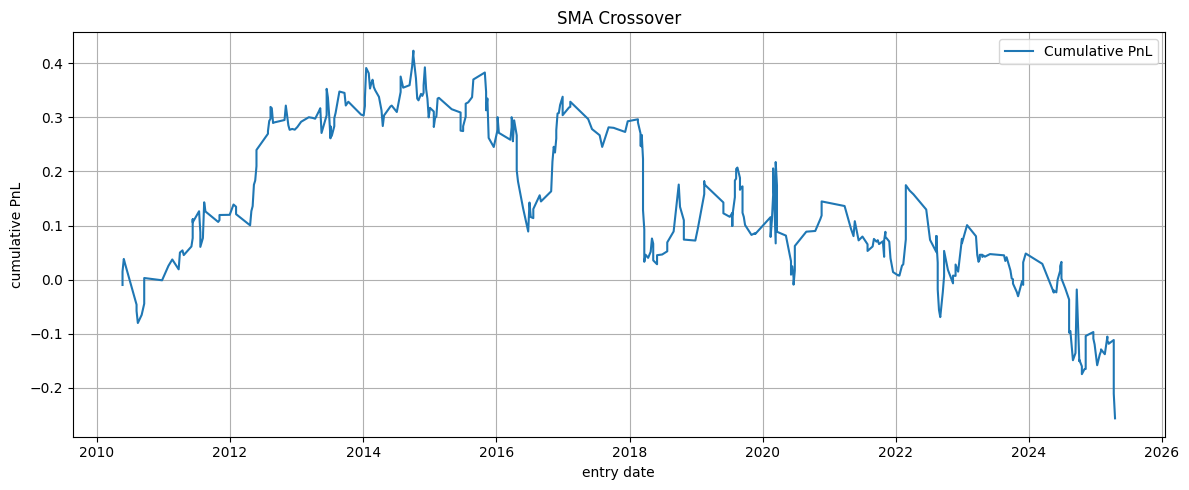

,mean,count,std,Sharpe
Ticker,,,,
CAC,0.005661,46,0.024142,0.234472
SPY,0.003876,35,0.034546,0.112204
EWH,0.002626,44,0.029114,0.090212
QQQ,0.002077,33,0.027126,0.076558
ISF,0.000346,67,0.016449,0.021052
INDA,-0.000038,36,0.030273,-0.001262
FEZ,-0.000676,41,0.023500,-0.028769
EWJ,-0.003267,59,0.025654,-0.127355
ASHR,-0.015949,40,0.040500,-0.393797


,Ticker,Entry Date,Exit Date,Direction,Entry Price,Exit Price,PnL,Cumulative PnL
24,SPY,2020-03-13,2020-03-20,Short,269.32,228.800,0.150453,0.217418
207,EWH,2024-09-20,2024-09-27,Long,16.76,18.730,0.117542,-0.018240
323,CAC,2022-02-25,2022-03-04,Short,66.50,59.840,0.100150,0.174638
271,INDA,2018-09-28,2018-10-05,Short,32.47,29.655,0.086695,0.175763
39,QQQ,2011-08-12,2011-08-19,Short,53.57,50.030,0.066082,0.142952
157,ASHR,2022-12-30,2023-01-06,Long,28.02,29.720,0.060671,0.075398
178,EWH,2014-01-17,2014-01-24,Short,20.61,19.460,0.055798,0.391281
267,INDA,2016-11-04,2016-11-11,Short,28.08,26.540,0.054843,0.218113
307,CAC,2016-07-01,2016-07-08,Short,43.49,41.160,0.053576,0.142522
141,ASHR,2019-02-08,2019-02-15,Long,23.81,25.030,0.051239,0.146030


,Ticker,Entry Date,Exit Date,Direction,Entry Price,Exit Price,PnL,Cumulative PnL
291,CAC,2012-04-27,2012-05-04,Short,32.765,31.90,0.026400,0.126754
299,CAC,2014-07-25,2014-08-01,Short,43.030,41.80,0.028585,0.375437
307,CAC,2016-07-01,2016-07-08,Short,43.490,41.16,0.053576,0.142522
317,CAC,2020-02-28,2020-03-06,Short,51.920,50.59,0.025616,0.182127
320,CAC,2020-11-13,2020-11-20,Long,53.060,54.23,0.022051,0.111993
322,CAC,2021-10-29,2021-11-05,Long,67.290,69.31,0.030019,0.072195
323,CAC,2022-02-25,2022-03-04,Short,66.500,59.84,0.100150,0.174638
325,CAC,2022-09-16,2022-09-23,Short,59.720,56.95,0.046383,-0.022931
328,CAC,2023-12-01,2023-12-08,Long,74.350,76.19,0.024748,0.032016


In [30]:

# Сортировка по дате
pnl_df = trade_pnl_df.copy()

pnl_df = pnl_df.sort_values("Entry Date").copy()
pnl_df["Cumulative PnL"] = pnl_df["PnL"].cumsum()

# График кумулятивного дохода
plt.figure(figsize=(12, 5))
plt.plot(pnl_df["Entry Date"], pnl_df["Cumulative PnL"], label="Cumulative PnL")
plt.title("SMA Crossover")
plt.xlabel("entry date")
plt.ylabel("cumulative PnL")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


pnl_by_ticker = pnl_df.groupby("Ticker")["PnL"].agg(["mean", "count", "std"])
pnl_by_ticker["Sharpe"] = pnl_by_ticker["mean"] / pnl_by_ticker["std"]

display(pnl_by_ticker.sort_values("Sharpe", ascending=False))

top10 = pnl_df.sort_values("PnL", ascending=False).head(10)
display(top10)



good_tickers = pnl_by_ticker[pnl_by_ticker["Sharpe"] > 0.2].index
trading_log_df = pnl_df[
    (pnl_df["PnL"] > 0.02) & (pnl_df["Ticker"].isin(good_tickers))
]

trading_log_df.to_csv("best_signals_trading_log.csv", index=False)
display(trading_log_df.head(10))


In [33]:
# С Notional = TBD
trading_log_ready = pd.DataFrame({
    "Trade Date": trading_log_df["Entry Date"],
    "Ticker": trading_log_df["Ticker"],
    "Signal": trading_log_df["Direction"],
    "Notional": "TBD",
    "Comments": "SMA crossover (Sharpe > 0.2, PnL > 2%) – pending final allocation"
})

log_ready_path = "Trading_Log_Ready.csv"
trading_log_ready.to_csv(log_ready_path, index=False)


trading_log_ready.head()


,Trade Date,Ticker,Signal,Notional,Comments
291,2012-04-27,CAC,Short,TBD,"SMA crossover (Sharpe > 0.2, PnL > 2%) – pendi..."
299,2014-07-25,CAC,Short,TBD,"SMA crossover (Sharpe > 0.2, PnL > 2%) – pendi..."
307,2016-07-01,CAC,Short,TBD,"SMA crossover (Sharpe > 0.2, PnL > 2%) – pendi..."
317,2020-02-28,CAC,Short,TBD,"SMA crossover (Sharpe > 0.2, PnL > 2%) – pendi..."
320,2020-11-13,CAC,Long,TBD,"SMA crossover (Sharpe > 0.2, PnL > 2%) – pendi..."


## with closest data


In [39]:
from datetime import datetime, timedelta


In [46]:

signal_date = pd.Timestamp("2025-04-18")
trade_date = pd.Timestamp("2025-04-22")


latest_signals = pnl_df[pnl_df["Entry Date"] == signal_date]

print(f"📌 Сигналов на {signal_date.date()}: {len(latest_signals)}")

if not latest_signals.empty:
    trading_log_latest = pd.DataFrame({
        "Trade Date": trade_date,
        "Ticker": latest_signals["Ticker"],
        "Signal": latest_signals["Direction"],
        "Notional": "TBD",
        "Comments": "SMA crossover signal from 2025-04-18"
    })

    # Сохраняем
    final_path = "Trading_Log_2025-04-22.csv"
    trading_log_latest.to_csv(final_path, index=False)

    print(f"📤 saved: {final_path}")
    display(trading_log_latest.head())
else:
    print("no signals")


📌 Сигналов на 2025-04-18: 1
📤 saved: Trading_Log_2025-04-22.csv


,Trade Date,Ticker,Signal,Notional,Comments
210,2025-04-22,EWH,Short,TBD,SMA crossover signal from 2025-04-18


In [45]:

last_signal_date = pnl_df["Entry Date"].max()
print(last_signal_date.date())


2025-04-18
